In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Добавим некоторые данные из pretrain набора

In [2]:
pretrain = pl.read_parquet("../data/pretrain_part_1.parquet")

In [3]:
pretrain = pretrain.with_columns(pl.col("event_dttm").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S")\
                                 .alias("event_dttm")).with_columns(pl.col("event_dttm").dt.hour().alias("Hour"))

# pretrain = pretrain.with_columns(pl.col("event_dttm").str.strptime(pl.Time, format="%H").alias("Hour"))

In [4]:
pre_agg = pretrain.group_by("customer_id").agg([
    pl.col("operaton_amt").mean().alias("mean_amt_pre"),
    pl.col("operaton_amt").median().alias("median_amt_pre"),
    pl.col("operaton_amt").std().alias("std_amt_pre"),
    pl.col("event_id").count().alias("ops_pre"),
    pl.col("Hour").mode().alias("most_common_hour_pre")])

pre_agg = pre_agg.with_columns(pl.col("most_common_hour_pre").list.first().alias("most_common_hour_pre"))
del pretrain
gc.collect()

0

In [5]:
pre_agg

customer_id,mean_amt_pre,median_amt_pre,std_amt_pre,ops_pre,most_common_hour_pre
i64,f64,f64,f64,u32,i8
123329281553662,6.1034e6,7.0119e6,5.2013e6,71,8
123406590968117,106705.504323,4393.0,462449.502667,643,7
123415180903629,780699.415842,496025.0,1.0681e6,408,13
123440950707188,226380.554023,40012.0,1.9315e6,1727,17
123140302993303,105069.186896,39636.0,285422.72566,1576,1
…,…,…,…,…,…
123217612407198,956021.515152,200970.0,2.4865e6,612,15
123217612407326,235009.833676,100135.0,432965.148905,1885,12
123440950705181,154534.15367,30222.0,744527.138064,696,9


Загрузим полный набор данных

In [6]:
train_part1 = pl.scan_parquet("../ClearData_for_part_4/train_full.parquet")
# train_part1.shape

In [7]:
train_part1.schema

/tmp/ipykernel_11240/896344679.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  train_part1.schema


Schema([('customer_id', Int64),
        ('event_dttm', String),
        ('event_type_nm', Int16),
        ('event_desc', Int16),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('timezone', Int16),
        ('session_id', Float64),
        ('operating_system_type', Int16),
        ('battery', String),
        ('device_system_version', String),
        ('screen_size', String),
        ('developer_tools', Int16),
        ('phone_voip_call_state', Int16),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [8]:
pos_class = train_part1.filter(pl.col("target") == 1).collect()
pos_class.shape

(51438, 22)

In [9]:
train_part1 = train_part1.filter(pl.col("target") != 1).collect()
train_part1.shape

(85626402, 22)

In [10]:
neg_class = 13_000_000
train_part1 = train_part1.sample(n=neg_class)

# columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
#            "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

# for i in columns:
#     train_part1 = train_part1.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

In [11]:
train_part1 = pl.concat([train_part1, pos_class])
train_part1 = train_part1.sample(fraction=1.0, shuffle=True)
train_part1.shape

(13051438, 22)

In [12]:
train_part1 = train_part1.sort("event_dttm")
train_part1 = train_part1.drop("event_dttm")

In [13]:
x = train_part1.drop("target")
y = train_part1["target"]

In [14]:
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle=False)   
X_train = x[:int(0.9*len(x))]
X_test = x[int(0.9*len(x)):]
y_train = y[:int(0.9*len(y))]
y_test = y[int(0.9*len(y)):]

In [15]:
# cat_features = ["event_type_nm", "event_desc", "channel_indicator_type", "channel_indicator_sub_type", \
#                 "currency_iso_cd", "mcc_code", "pos_cd", "timezone", "operating_system_type", "battery",\
#                 "device_system_version", "screen_size", \
#                 "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised"]

# cat_features = [
#     'mcc_code', 'event_desc', 'channel_indicator_type',
#     'timezone', 'operating_system_type', 'device_system_version',
#     'screen_size', 'battery'
# ]

columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
           "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

for i in columns:
    X_train = X_train.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

for i in columns:
    X_test = X_test.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))

cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery'
]

for i in cat_features:
    X_train = X_train.with_columns(pl.col(i).fill_null('missing'))

for i in cat_features:
    X_test = X_test.with_columns(pl.col(i).fill_null('missing'))

In [16]:
X_train = X_train.with_columns(pl.concat_str([pl.col("operating_system_type"), pl.col("device_system_version"), 
    pl.col("screen_size"), pl.col("battery")], separator="_").alias("device_info"))

X_test = X_test.with_columns(pl.concat_str([pl.col("operating_system_type"), pl.col("device_system_version"), 
    pl.col("screen_size"), pl.col("battery")], separator="_").alias("device_info"))

In [17]:
X_train = X_train.join(pre_agg, on="customer_id", how="left")
X_test = X_test.join(pre_agg, on="customer_id", how="left")

X_train = X_train.drop("customer_id")
X_test = X_test.drop("customer_id")

# # Новые фичи
# X_train = X_train.with_columns([
#     (pl.col("operaton_amt") / pl.col("mean_amt_pre")).alias("amount_ratio_pre"),
#     ((pl.col("operaton_amt") - pl.col("mean_amt_pre")) / (pl.col("std_amt_pre") + 1)).alias("amt_zscore_pre")])

# X_test = X_test.with_columns([
#     (pl.col("operaton_amt") / pl.col("mean_amt_pre")).alias("amount_ratio_pre"),
#     ((pl.col("operaton_amt") - pl.col("mean_amt_pre")) / (pl.col("std_amt_pre") + 1)).alias("amt_zscore_pre")])

In [18]:
X_train

event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,timezone,session_id,operating_system_type,battery,device_system_version,screen_size,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,Hour,device_info,mean_amt_pre,median_amt_pre,std_amt_pre,ops_pre,most_common_hour_pre
i16,str,i16,i16,f64,i16,str,i16,str,f64,str,str,str,str,i16,i16,i16,i16,i16,str,f64,f64,f64,u32,i8
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",182607.317013,23640.0,2.2548e6,1396,10
14,"""75""",6,5,29822.0,0,"""missing""",4,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null
14,"""75""",6,5,30154.0,0,"""missing""",4,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null
14,"""75""",6,5,5902.0,0,"""4""",3,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,0,"""missing_missing_missing_missin…",null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",1.2399e14,"""missing""","""missing""","""15""","""1220x2441""",0,0,null,0,3,"""missing_15_1220x2441_missing""",3.6657e6,36325.0,1.5899e7,998,5
14,"""36""",4,15,500500.0,0,"""missing""",null,"""missing""",1.2402e14,"""missing""","""missing""","""15""","""1220x2712""",0,0,null,0,3,"""missing_15_1220x2712_missing""",null,null,null,null,null
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",1.2579e14,"""missing""","""missing""","""10""","""1080x2316""",0,0,null,0,3,"""missing_10_1080x2316_missing""",null,null,null,null,null


In [19]:
del train_part1, x, y
gc.collect()

0

In [20]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [21]:
cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery', 'device_info']

In [22]:
# CatBoost = CatBoostClassifier(iterations=50, depth=5, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

In [23]:
# train_models(CatBoost, X_train, X_test, y_train, y_test)

Попробуем настроить веса меток самостоятельно

In [24]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9440898550640738
Precision: 0.02935714153498732
Recall: 0.4092111204283042
F1-score: 0.05478403168677074
PR-AUC: 0.049824015628124316

Test metrics:
Accuracy: 0.9534181668842672
Precision: 0.031199127297138543
Recall: 0.37715560965713124
F1-score: 0.05763090181976005
PR-AUC: 0.04443812118110117

Confusion matrix


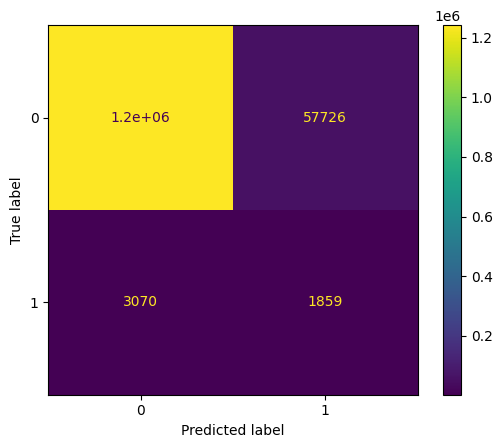

In [25]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [26]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=6, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9437508545248399
Precision: 0.030048264527561586
Recall: 0.4221978541787611
F1-score: 0.05610357847458039
PR-AUC: 0.05320606399250521

Test metrics:
Accuracy: 0.9539276892051758
Precision: 0.02995572207084469
Recall: 0.3568675187664841
F1-score: 0.05527188172634291
PR-AUC: 0.04303910258714235

Confusion matrix


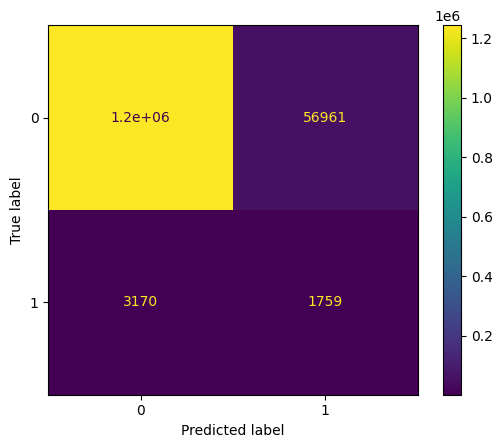

In [27]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [28]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,operaton_amt,16.983228
1,ops_pre,8.217701
2,median_amt_pre,7.145570
3,pos_cd,6.720599
4,mean_amt_pre,6.512858
5,mcc_code,6.347684
6,event_type_nm,6.315515
7,most_common_hour_pre,6.292364
8,Hour,6.130519
9,std_amt_pre,5.328809


In [29]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9419569270103405
Precision: 0.030562690462607997
Recall: 0.4446451224494184
F1-score: 0.05719414064282563
PR-AUC: 0.05750293249213326

Test metrics:
Accuracy: 0.9516382866564915
Precision: 0.029663756870352408
Recall: 0.37228646784337593
F1-score: 0.05494916827621315
PR-AUC: 0.0414689688795001

Confusion matrix


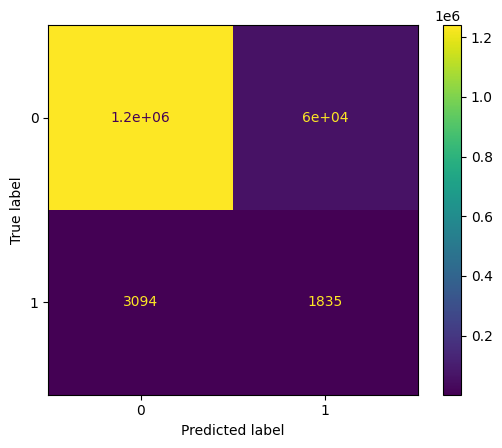

In [30]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [31]:
cat_features = [
    'mcc_code', 'event_desc', 'channel_indicator_type',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery', 'device_info']

In [32]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=100, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9414743918379703
Precision: 0.030318441092501508
Recall: 0.44479563095314884
F1-score: 0.05676746250512806
PR-AUC: 0.05832340813404076

Test metrics:
Accuracy: 0.9514942412484753
Precision: 0.029907234426335114
Recall: 0.3767498478393183
F1-score: 0.05541546679398995
PR-AUC: 0.04300598929589206

Confusion matrix


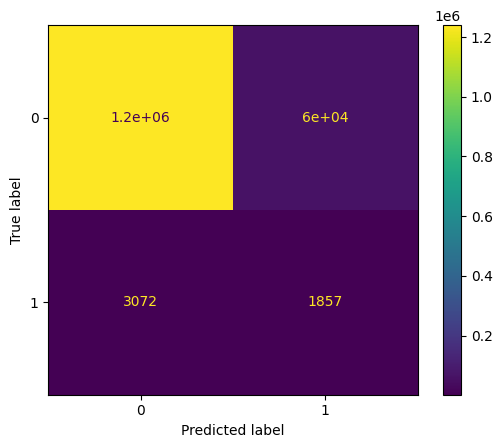

In [33]:
train_models(CatBoost, X_train, X_test, y_train, y_test)